In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import networkx as nx
import ast
import numpy as np



# ==========================================================
# 1. CARGA DE DATOS Y EXTRACCIÓN DE TRANSICIONES
# ==========================================================

# Cargamos el dataframe (asegurate de que la ruta sea correcta)
trayectorias = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/revision_dfs.xlsx", sheet_name=2)
df_pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/revision_dfs.xlsx", sheet_name=0)


# Usamos un Counter para contar cuántas veces se pasa de un Nivel A a un Nivel B
transiciones = Counter()
niveles_unicos = set()

# Recorremos cada trayectoria para extraer los niveles y sus saltos
for ruta in trayectorias['ruta_complejidad_str'].dropna():
    nodos = [n.strip() for n in str(ruta).split('->')]
    
    # Guardamos los niveles únicos para armar los ejes de la matriz
    for n in nodos:
        niveles_unicos.add(n)
        
    # Contamos las transiciones (origen -> destino)
    for i in range(len(nodos)-1):
        transiciones[(nodos[i], nodos[i+1])] += 1

# Ordenamos los niveles. 
# NOTA: Si tus niveles son strings como 'Baja', 'Media', 'Alta', te conviene 
# forzar el orden manualmente así: niveles = ['Baja', 'Media', 'Alta']
niveles = sorted(list(niveles_unicos))

In [2]:
# ==========================================================
# 2. CONSTRUCCIÓN DE LAS MATRICES (DATAFRAMES)
# ==========================================================

# Matriz de Cantidades
df_cantidades = pd.DataFrame(0, index=niveles, columns=niveles)

for (origen, destino), cantidad in transiciones.items():
    df_cantidades.at[origen, destino] = cantidad

# Matriz de Probabilidades (Frecuencia relativa por fila)
# Dividimos cada celda por la suma total de su fila (hospital de origen)
df_probabilidades = df_cantidades.div(df_cantidades.sum(axis=1), axis=0).fillna(0)


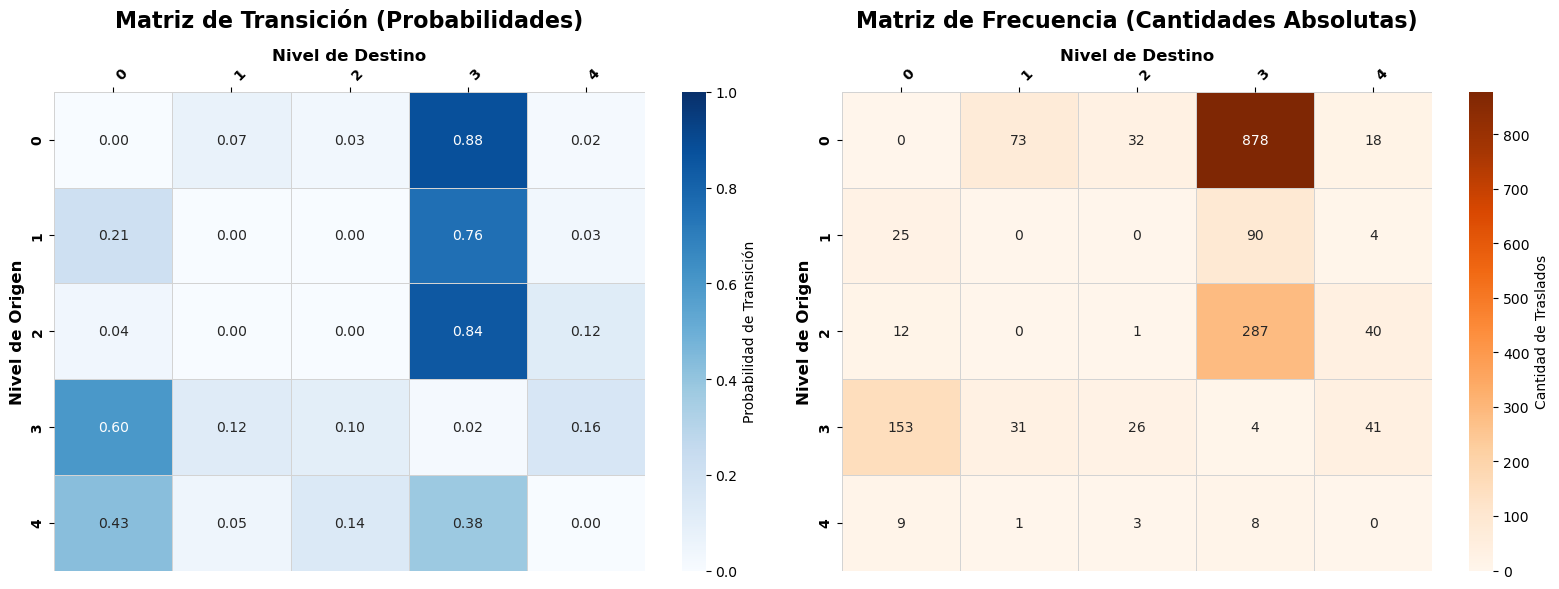

In [3]:
# ==========================================================
# 3. VISUALIZACIÓN (heatmaps)
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# -- Gráfico 1: Probabilidades --
sns.heatmap(df_probabilidades, annot=True, fmt=".2f", cmap="Blues", 
            linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1, ax=axes[0],
            cbar_kws={'label': 'Probabilidad de Transición'})

axes[0].set_title("Matriz de Transición (Probabilidades)", fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

# -- Gráfico 2: Cantidades --
sns.heatmap(df_cantidades, annot=True, fmt="d", cmap="Oranges", 
            linewidths=0.5, linecolor='lightgray', ax=axes[1],
            cbar_kws={'label': 'Cantidad de Traslados'})

axes[1].set_title("Matriz de Frecuencia (Cantidades Absolutas)", fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

# Mejoras estéticas para ambos gráficos
for ax in axes:
    ax.xaxis.tick_top() # Eje X arriba (estándar en matrices de transición)
    ax.xaxis.set_label_position('top')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='left', fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\micag\AppData\Local\Temp\ipykernel_33836\4254121522.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Frecuencia', y='Ruta', palette='viridis', ax=ax)


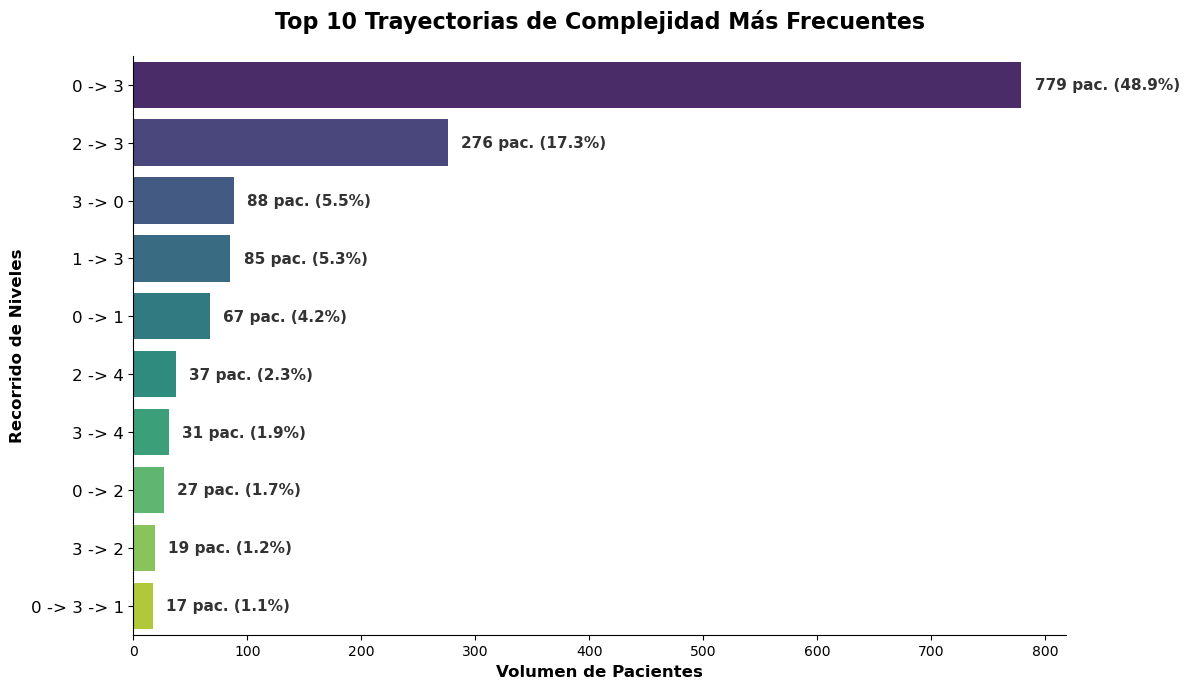

In [4]:
# ==========================================================
# 4. CÁLCULO DE FRECUENCIAS Y PORCENTAJES (TOP 10)
# ==========================================================

# Contamos las rutas y nos quedamos con las 10 principales
top_10 = trayectorias['ruta_complejidad_str'].value_counts().head(10).reset_index()
top_10.columns = ['Ruta', 'Frecuencia']

# Calculamos qué porcentaje representa cada ruta sobre el total de pacientes evaluados
total_pacientes = len(trayectorias.dropna(subset=['ruta_complejidad_array']))
top_10['Porcentaje'] = (top_10['Frecuencia'] / total_pacientes) * 100

# ==========================================================
# 5. VISUALIZACIÓN: GRÁFICO DE BARRAS HORIZONTALES
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

# Dibujamos las barras horizontales usando una paleta que resalte los valores más altos
sns.barplot(data=top_10, x='Frecuencia', y='Ruta', palette='viridis', ax=ax)

# Agregamos las etiquetas de datos (Cantidad y Porcentaje) al final de cada barra
margen = top_10['Frecuencia'].max() * 0.015 # Un pequeño margen para que el texto no se pegue a la barra

for index, row in top_10.iterrows():
    texto_etiqueta = f"{int(row['Frecuencia'])} pac. ({row['Porcentaje']:.1f}%)"
    ax.text(row['Frecuencia'] + margen, index, texto_etiqueta, 
            color='#333333', va="center", fontweight='bold', fontsize=11)

# Estética y limpieza visual
ax.set_title("Top 10 Trayectorias de Complejidad Más Frecuentes", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Volumen de Pacientes", fontsize=12, fontweight='bold')
ax.set_ylabel("Recorrido de Niveles", fontsize=12, fontweight='bold')

# Ocultar los bordes superior y derecho para un look más limpio (estilo reporte)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Agrandar un poco el tamaño de las rutas en el eje Y para mejor lectura
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

C:\Users\micag\AppData\Local\Temp\ipykernel_33836\3673454183.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_saltos, x='Frecuencia', y='Salto', palette='viridis', ax=ax)


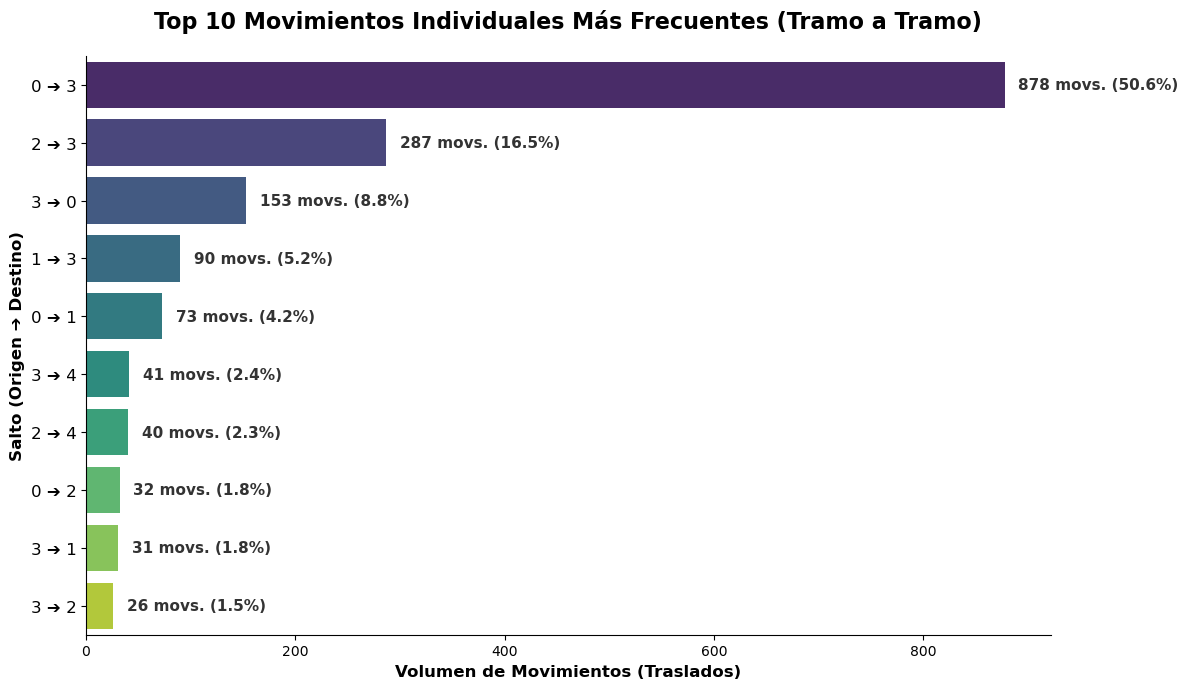

In [5]:
# ==========================================================
# 4 (MODIFICADO). CÁLCULO DE FRECUENCIAS Y PORCENTAJES POR SALTO INDIVIDUAL
# ==========================================================

# 1. Convertimos el Counter 'transiciones' (que calculaste en el bloque 1) a un DataFrame
df_saltos = pd.DataFrame(transiciones.items(), columns=['Salto_Tupla', 'Frecuencia'])

# 2. Formateamos la tupla (origen, destino) para que se lea lindo en el eje Y (ej: "0 ➔ 3")
df_saltos['Salto'] = df_saltos['Salto_Tupla'].apply(lambda x: f"{x[0]} ➔ {x[1]}")

# 3. Ordenamos de mayor a menor y nos quedamos con el Top 10
top_10_saltos = df_saltos.sort_values(by='Frecuencia', ascending=False).head(10).reset_index(drop=True)

# 4. Cálculo del porcentaje
# ATENCIÓN: Como ahora contamos saltos individuales, un paciente puede generar varios saltos. 
# Por lo tanto, el porcentaje lo calculamos sobre el TOTAL DE MOVIMIENTOS de la red, no de pacientes.
total_movimientos = df_saltos['Frecuencia'].sum()
top_10_saltos['Porcentaje'] = (top_10_saltos['Frecuencia'] / total_movimientos) * 100

# ==========================================================
# 5 (MODIFICADO). VISUALIZACIÓN: GRÁFICO DE BARRAS HORIZONTALES (SALTOS)
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

# Dibujamos las barras apuntando al nuevo DataFrame 'top_10_saltos'
sns.barplot(data=top_10_saltos, x='Frecuencia', y='Salto', palette='viridis', ax=ax)

# Agregamos las etiquetas de datos al final de cada barra
margen = top_10_saltos['Frecuencia'].max() * 0.015 

for index, row in top_10_saltos.iterrows():
    # Nota: Cambié el sufijo "pac." por "movs." para reflejar que estamos contando traslados
    texto_etiqueta = f"{int(row['Frecuencia'])} movs. ({row['Porcentaje']:.1f}%)"
    ax.text(row['Frecuencia'] + margen, index, texto_etiqueta, 
            color='#333333', va="center", fontweight='bold', fontsize=11)

# Estética y limpieza visual actualizadas al nuevo contexto
ax.set_title("Top 10 Movimientos Individuales Más Frecuentes (Tramo a Tramo)", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Volumen de Movimientos (Traslados)", fontsize=12, fontweight='bold')
ax.set_ylabel("Salto (Origen ➔ Destino)", fontsize=12, fontweight='bold')

# Ocultar bordes superior y derecho
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Tamaño de las etiquetas del eje Y
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

C:\Users\micag\AppData\Local\Temp\ipykernel_33836\112066813.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_viajes, x='Frecuencia', y='Viaje_Global', palette='rocket', ax=ax)


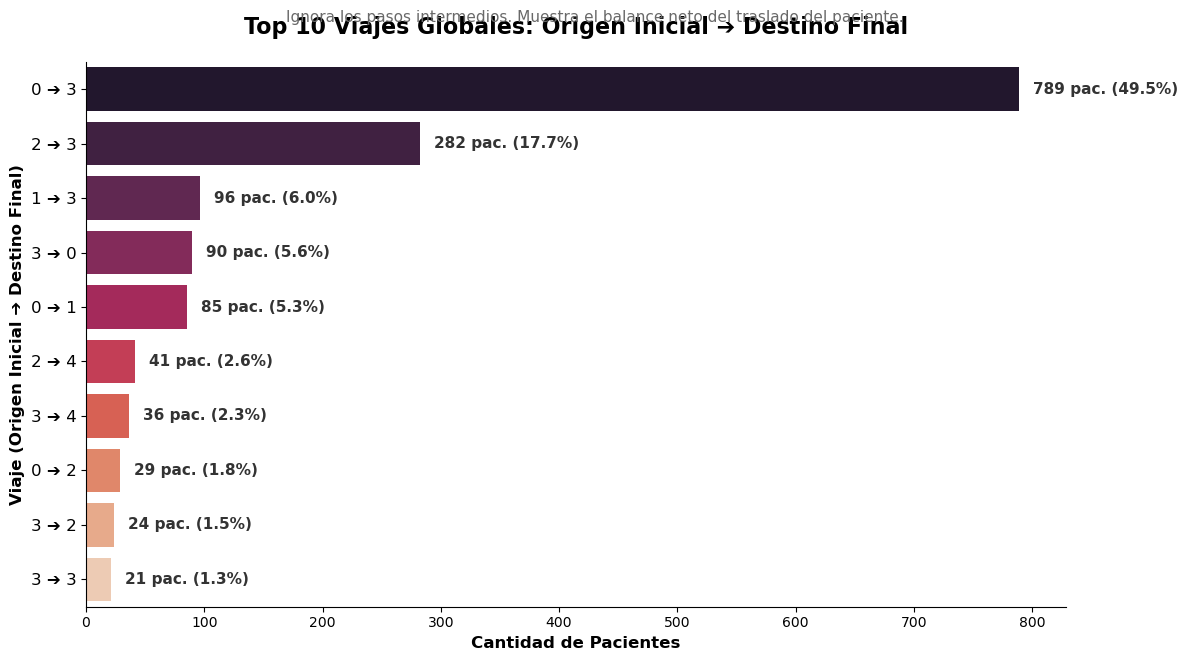

In [6]:
import ast

# ==========================================================
# NUEVO BLOQUE: VIAJE GLOBAL (ORIGEN INICIAL ➔ DESTINO FINAL)
# ==========================================================

# 1. Función para extraer solo el primer y último nivel de la ruta
def extraer_origen_destino_final(valor):
    # Intentamos parsear el string a lista de Python
    if isinstance(valor, str) and valor.startswith('['):
        try:
            lista = ast.literal_eval(valor)
        except:
            return None
    elif isinstance(valor, list):
        lista = valor
    else:
        return None
    
    # Si la lista tiene elementos, tomamos el primero (índice 0) y el último (índice -1)
    if len(lista) > 0:
        origen = lista[0]
        destino = lista[-1]
        return f"{origen} ➔ {destino}"
    return None

# 2. Aplicamos la función para crear una nueva columna
trayectorias['viaje_global'] = trayectorias['ruta_complejidad_array'].apply(extraer_origen_destino_final)

# 3. Filtramos posibles nulos y contamos las frecuencias de estos viajes globales
df_viajes = trayectorias.dropna(subset=['viaje_global'])
top_10_viajes = df_viajes['viaje_global'].value_counts().head(10).reset_index()
top_10_viajes.columns = ['Viaje_Global', 'Frecuencia']

# 4. Cálculo del porcentaje (ahora volvemos a hablar de pacientes únicos)
total_pacientes_validos = len(df_viajes)
top_10_viajes['Porcentaje'] = (top_10_viajes['Frecuencia'] / total_pacientes_validos) * 100

# ==========================================================
# VISUALIZACIÓN: GRÁFICO DE BARRAS (VIAJES GLOBALES)
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

# Dibujamos las barras usando el nuevo DataFrame
sns.barplot(data=top_10_viajes, x='Frecuencia', y='Viaje_Global', palette='rocket', ax=ax)

# Agregamos las etiquetas de datos al final de cada barra
margen = top_10_viajes['Frecuencia'].max() * 0.015 

for index, row in top_10_viajes.iterrows():
    # Volvemos a usar "pac." porque aquí cada fila evaluada es el viaje total de 1 paciente
    texto_etiqueta = f"{int(row['Frecuencia'])} pac. ({row['Porcentaje']:.1f}%)"
    ax.text(row['Frecuencia'] + margen, index, texto_etiqueta, 
            color='#333333', va="center", fontweight='bold', fontsize=11)

# Estética y limpieza visual
ax.set_title("Top 10 Viajes Globales: Origen Inicial ➔ Destino Final", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Cantidad de Pacientes", fontsize=12, fontweight='bold')
ax.set_ylabel("Viaje (Origen Inicial ➔ Destino Final)", fontsize=12, fontweight='bold')

# Subtítulo explicativo
plt.figtext(0.5, 0.92, "Ignora los pasos intermedios. Muestra el balance neto del traslado del paciente.", 
            ha="center", fontsize=11, color='dimgray')

# Ocultar bordes superior y derecho
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='y', labelsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajustamos para que entre el subtítulo
plt.show()

In [7]:
# trayectorias.columns

In [8]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# ==========================================================
# 1. DEFINICIÓN DE TUS PERÍODOS TEMPORALES
# ==========================================================
periodos = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]

# Función para categorizar la fecha del paciente en tu periodo correspondiente
def asignar_periodo(fecha):
    if pd.isna(fecha):
        return 'Sin Dato/Otro'
    
    # Convertimos la fecha a string (YYYY-MM-DD) para comparar fácilmente
    fecha_str = str(fecha)[:10] 
    
    for nombre, inicio, fin in periodos:
        if inicio <= fecha_str <= fin:
            return nombre
    return 'Fuera de rango'

# Aplicamos la función (Reemplaza 'fecha_ingreso' por el nombre real de tu columna de fechas)
# Si no tienes la fecha en 'trayectorias', tendrás que hacerle un pd.merge() con df_pacientes antes.
trayectorias['Periodo_Covid'] = trayectorias['fecha_ingreso_trayectoria'].apply(asignar_periodo)
# ==========================================================
# 2. EXTRACCIÓN DE SALTOS CON SU PERÍODO ASIGNADO (CORREGIDO)
# ==========================================================

saltos_temporales = []

# Cambiamos 'lista_nodos' por 'ruta_complejidad_str'
for idx, row in trayectorias.dropna(subset=['ruta_complejidad_str']).iterrows():
    
    # Convertimos el string "A -> B -> C" en una lista real ['A', 'B', 'C']
    ruta = [n.strip() for n in str(row['ruta_complejidad_str']).split('->')]
    periodo = row['Periodo_Covid']
    
    # Si la ruta tiene más de un nodo (es decir, hubo al menos un traslado)
    if len(ruta) > 1:
        for i in range(len(ruta) - 1):
            origen = ruta[i]
            destino = ruta[i+1]
            
            saltos_temporales.append({
                'Salto': f"{origen} ➔ {destino}",
                'Periodo': periodo
            })

df_saltos_temp = pd.DataFrame(saltos_temporales)

# Filtramos solo los que caen dentro de los 4 periodos principales (ignoramos nulos/fuera de rango)
df_saltos_temp = df_saltos_temp[df_saltos_temp['Periodo'].isin([p[0] for p in periodos])]
# ==========================================================
# 3. CREACIÓN DE LA MATRIZ PIVOT PARA BARRAS APILADAS
# ==========================================================

# Identificamos el Top 10 general para saber qué filas dibujar
top_10_saltos = df_saltos_temp['Salto'].value_counts().head(10).index

# Filtramos el df para quedarnos solo con ese Top 10
df_top10_temp = df_saltos_temp[df_saltos_temp['Salto'].isin(top_10_saltos)]

# Armamos el pivot table
pivot_periodos = pd.crosstab(df_top10_temp['Salto'], df_top10_temp['Periodo'])

# Ordenamos las filas (eje Y) de mayor a menor volumen total
pivot_periodos['Total'] = pivot_periodos.sum(axis=1)
pivot_periodos = pivot_periodos.sort_values('Total', ascending=True) # Ascendente para barh
pivot_periodos = pivot_periodos.drop(columns=['Total'])

# Forzamos el orden cronológico de las columnas (las Olas) para que la leyenda tenga sentido lógico
orden_columnas = [p[0] for p in periodos if p[0] in pivot_periodos.columns]
pivot_periodos = pivot_periodos[orden_columnas]

# # # ==========================================================
# # # 4. VISUALIZACIÓN: BARRAS APILADAS POR PERÍODO (OLA)
# # # ==========================================================

# # Usamos una paleta distinta para que no se confunda con el gráfico de ingresos
# colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))

# fig, ax = plt.subplots(figsize=(12, 8))
# fig.patch.set_facecolor('white')

# # Dibujamos las barras apiladas
# pivot_periodos.plot(kind='barh', stacked=True, color=colores_periodos, ax=ax, width=0.75)

# # Agregamos los totales al final de la barra
# for i, (idx, row) in enumerate(pivot_periodos.iterrows()):
#     total_barra = row.sum()
#     ax.text(total_barra + (pivot_periodos.values.sum() * 0.005), i, 
#             f" {int(total_barra)}", 
#             va='center', fontweight='bold', color='#333333', fontsize=11)

# ax.set_title("Top 10 Saltos de Complejidad divididos por Período de Pandemia", fontsize=16, fontweight='bold', pad=20)
# ax.set_xlabel("Volumen Total de Traslados", fontsize=12, fontweight='bold')
# ax.set_ylabel("Salto de Complejidad (Origen ➔ Destino)", fontsize=12, fontweight='bold')

# # Leyenda
# ax.legend(title="Período Temporal", title_fontsize='12', fontsize='11', 
#           loc='lower right', frameon=True, facecolor='white')

# sns.despine()
# plt.tight_layout()
# plt.show()

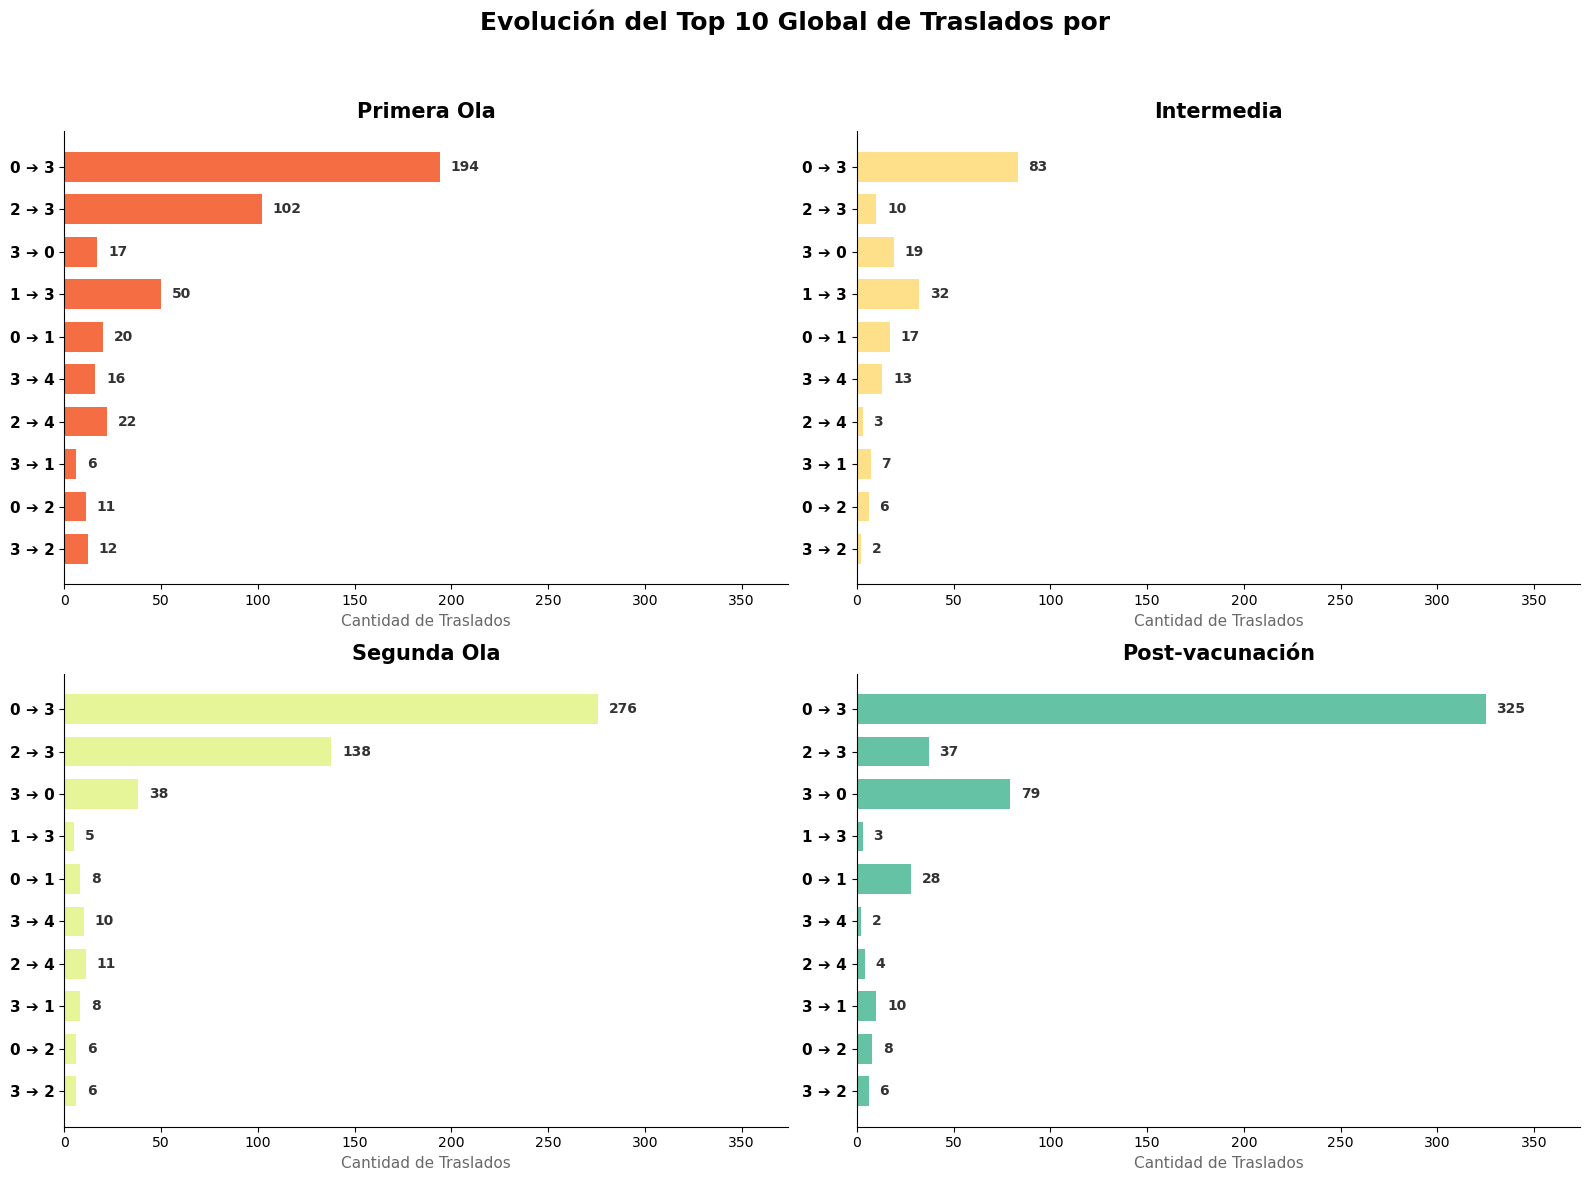

In [9]:
# ==========================================================
# 7. VISUALIZACIÓN: GRILLA 2x2 POR PERÍODO (OLAS COVID)
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')
axes = axes.flatten() # Aplanamos la matriz 2x2 a un array de 4 elementos para iterar fácil

# Reutilizamos la paleta de colores para que coincida con el gráfico anterior
colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))

# 🌟 TRUCO CLAVE: Calculamos el máximo general para fijar el Eje X de los 4 gráficos igual.
# Si no hacemos esto, Matplotlib ajustará cada gráfico a su propio tamaño y engañará al ojo.
max_x = pivot_periodos.max().max() * 1.15 # Le damos un 15% de margen para que entren los numeritos

for idx, periodo in enumerate(orden_columnas):
    ax = axes[idx]
    
    # Extraemos los datos de ese periodo específico respetando el orden global
    valores = pivot_periodos[periodo]
    y_pos = np.arange(len(valores))
    
    # Dibujamos las barras horizontales
    ax.barh(y_pos, valores, color=colores_periodos[idx], height=0.7)
    
    # Configuramos el Eje Y con los nombres de los saltos
    ax.set_yticks(y_pos)
    ax.set_yticklabels(valores.index, fontweight='bold', fontsize=11)
    
    # Fijamos el límite del Eje X para que todos los subplots tengan la misma escala
    ax.set_xlim(0, max_x)
    
    # Títulos y etiquetas
    ax.set_title(f"{periodo}", fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel("Cantidad de Traslados", fontsize=11, color='dimgray')
    
    # Agregamos la etiqueta de texto con el valor al final de la barra
    for i, v in enumerate(valores):
        if v > 0: # Solo ponemos número si hubo traslados en ese periodo
            ax.text(v + (max_x * 0.015), i, str(int(v)), 
                    va='center', fontweight='bold', color='#333333', fontsize=10)

    # Limpieza visual de bordes
    sns.despine(ax=ax)

# Título general de la figura completa
plt.suptitle("Evolución del Top 10 Global de Traslados por", 
             fontsize=18, fontweight='bold', y=0.98)

# Ajustamos el layout dejando un poco de espacio superior (0.95) para el suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import ast

# ==========================================================
# 8. VISUALIZACIÓN: INGRESOS REALES AL SISTEMA POR COMPLEJIDAD
# ==========================================================

# 1. Función robusta para extraer el nivel de ingreso (primer elemento)
def obtener_nivel_ingreso(valor):
    if isinstance(valor, str) and valor.startswith('['):
        try:
            lista = ast.literal_eval(valor)
            return int(lista[0]) if len(lista) > 0 else None
        except:
            return None
    elif isinstance(valor, list) and len(valor) > 0:
        return int(valor[0])
    return None

# Aplicamos la función
trayectorias['nivel_ingreso'] = trayectorias['ruta_complejidad_array'].apply(obtener_nivel_ingreso)

# 2. Contamos cuántos pacientes ingresaron por cada nivel (quitando nulos por si acaso)
ingresos_reales = trayectorias.dropna(subset=['nivel_ingreso'])['nivel_ingreso'].value_counts().sort_index().reset_index()
ingresos_reales.columns = ['Nivel', 'Ingresos']

# Ahora sí es seguro convertir a string para el gráfico categórico
ingresos_reales['Nivel'] = ingresos_reales['Nivel'].astype(int).astype(str)

# ==========================================================
# CONFIGURACIÓN DE COLORES Y DIBUJO DEL GRÁFICO
# ==========================================================
# El Nivel 0 con un azul profundo vibrante, el resto en un gris claro neutro
colores = ['#08519c' if nivel == '0' else '#d9d9d9' for nivel in ingresos_reales['Nivel']]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

# Dibujamos el gráfico de barras
barras = ax.bar(ingresos_reales['Nivel'], ingresos_reales['Ingresos'], color=colores, width=0.6)

# Agregamos las etiquetas de datos justo encima de cada barra
max_ingresos = ingresos_reales['Ingresos'].max()

for barra in barras:
    altura = barra.get_height()
    
    # Para el Nivel 0, la etiqueta va en el mismo color azul y en negrita
    color_texto = '#08519c' if barra.get_x() == barras[0].get_x() else '#666666'
    
    ax.text(barra.get_x() + barra.get_width()/2., altura + (max_ingresos * 0.02),
            f"{int(altura):,}".replace(',', '.'), # Formateador de miles
            ha='center', va='bottom', fontweight='bold', fontsize=12, color=color_texto)

# ==========================================================
# ANOTACIÓN CLAVE
# ==========================================================
# texto_nota = ("Nota Operativa: La masiva cantidad de ingresos\n"
#               "totales en el Nivel 0 se debe a su escala operativa\n"
#               "y su función como principal punto de entrada al\n"
#               "complejo hospitalario que comparte predio con el Nivel 3.")

# # ax.annotate para la flecha y el recuadro dinámico
# x_nivel_0 = ingresos_reales[ingresos_reales['Nivel'] == '0'].index[0]

# ax.annotate(texto_nota,
#             xy=(x_nivel_0, max_ingresos * 0.75),  # Punto al que apunta la flecha
#             xytext=(x_nivel_0 + 0.8, max_ingresos * 0.85), # Posición del texto
#             fontsize=11, color='#333333', style='italic',
#             bbox=dict(boxstyle="round,pad=0.5", fc="#f2f2f2", ec="lightgray", lw=1),
#             arrowprops=dict(arrowstyle="->", color="#08519c", lw=1.5, connectionstyle="arc3,rad=0.1"))

# ==========================================================
# ESTÉTICA Y LIMPIEZA VISUAL
# ==========================================================
ax.set_title("Comparativa del Volumen Total de Ingresos (Entradas al Sistema) por Nivel de Complejidad", 
             fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel("Nivel de Complejidad", fontsize=12, fontweight='bold')

# Quitamos el eje Y para que sea aún más limpio
ax.get_yaxis().set_visible(False)

# Ocultamos los bordes innecesarios
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

ax.tick_params(axis='x', labelsize=14, length=0) 

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Cheque de representatividad de este top 10
# ==========================================================

# proporcion

total_pacientes_red = len(trayectorias.dropna(subset=['ruta_complejidad_array']))
pacientes_en_top_10 = top_10.sum()
porcentaje_cobertura = (pacientes_en_top_10 / total_pacientes_red) * 100

print(f"Total de pacientes en la red: {total_pacientes_red}")
print(f"Pacientes dentro del Top 10: {pacientes_en_top_10}")
print(f"El Top 10 representa el {porcentaje_cobertura:.2f}% del total de movimientos.")

In [ ]:
# # ==========================================================
# # 6. EXTRACCIÓN Y LIMPIEZA DEL TOP 10
# # ==========================================================

# # Aseguramos que la columna sea una lista real de Python
# def parsear_array(valor):
#     if isinstance(valor, str) and valor.startswith('['):
#         try:
#             return ast.literal_eval(valor)
#         except:
#             return []
#     elif isinstance(valor, list):
#         return valor
#     return []

# trayectorias['lista_nodos'] = trayectorias['ruta_complejidad_array'].apply(parsear_array)

# # Filtramos filas vacías y convertimos a tuplas para poder contarlas
# rutas_validas = trayectorias[trayectorias['lista_nodos'].map(len) > 0]['lista_nodos'].apply(tuple)

# # Obtenemos las 10 rutas más frecuentes con su cantidad exacta
# top_10_rutas = rutas_validas.value_counts().head(10)

# # ==========================================================
# # 7. CONSTRUCCIÓN DEL GRAFO DIRIGIDO (PONDERADO)
# # ==========================================================

# G_top10 = nx.DiGraph()
# pesos_nodos = Counter()
# pesos_aristas = Counter()

# # Calculamos el peso de cada nodo y arista multiplicando por la frecuencia de la ruta
# for ruta, frecuencia in top_10_rutas.items():
#     # Sumar peso a los nodos
#     for nodo in ruta:
#         pesos_nodos[nodo] += frecuencia
        
#     # Sumar peso a las transiciones (aristas)
#     for i in range(len(ruta) - 1):
#         origen = ruta[i]
#         destino = ruta[i+1]
#         pesos_aristas[(origen, destino)] += frecuencia

# # Agregamos los datos al grafo de NetworkX
# for nodo, peso in pesos_nodos.items():
#     G_top10.add_node(nodo, weight=peso)

# for (origen, destino), peso in pesos_aristas.items():
#     G_top10.add_edge(origen, destino, weight=peso)

# # ==========================================================
# # 8. VISUALIZACIÓN DE LA RED
# # ==========================================================
# import matplotlib.pyplot as plt
# from netgraph import Graph # Requiere: pip install netgraph

# fig, ax = plt.subplots(figsize=(10, 8))
# fig.patch.set_facecolor('white')
# ax.axis('off')

# posiciones = nx.circular_layout(G_top10)
# etiquetas_aristas = {(u, v): d['weight'] for u, v, d in G_top10.edges(data=True)}

# pesos = [d['weight'] for _, _, d in G_top10.edges(data=True)]
# max_peso = max(pesos) if pesos else 1

# grosores_aristas = {
#     (u, v): 1 + 4 * (d['weight'] / max_peso)
#     for u, v, d in G_top10.edges(data=True)
# }
# # Netgraph se encarga de dibujar todo junto y calcula las curvas automáticamente
# Graph(G_top10, 
#       node_layout=posiciones,
#       node_color='skyblue',
#       node_size=6, # Netgraph maneja las escalas distinto
#       node_edge_width=1.5,
#       node_labels=True, # Usa los nombres de los nodos automáticamente
#       node_label_fontdict=dict(size=14, weight='bold'),
#       edge_layout='curved', 
#       edge_color='gray',
#       edge_width=grosores_aristas,
#       edge_labels=etiquetas_aristas,
#       edge_label_fontdict=dict(size=11, weight='bold', color='red'),
#       arrows=True,
#       ax=ax)

# ax.set_title("Red de Transiciones: Top 10 Trayectorias Más Frecuentes", 
#              fontsize=16, fontweight='bold', pad=20)

# plt.tight_layout()
# plt.show()

In [ ]:
# # ==========================================================
# # 9. FILTRADO Y PROCESAMIENTO
# # ==========================================================

# # Función para asegurar que los datos sean listas y no strings
# def obtener_ultimo_nivel(valor):
#     if isinstance(valor, str) and valor.startswith('['):
#         try:
#             lista = ast.literal_eval(valor)
#             return lista[-1] if len(lista) > 0 else None
#         except:
#             return None
#     elif isinstance(valor, list):
#         return valor[-1] if len(valor) > 0 else None
#     return None

# # Creamos una columna temporal con el destino final
# trayectorias['destino_final'] = trayectorias['ruta_complejidad_array'].apply(obtener_ultimo_nivel)

# # Filtramos: Solo los que terminan en nivel 4
# df_nivel_4 = trayectorias[trayectorias['destino_final'] == 4].copy()

# # Calculamos métricas globales
# total_general = len(trayectorias.dropna(subset=['ruta_complejidad_array']))
# total_terminan_4 = len(df_nivel_4)
# porcentaje_global_4 = (total_terminan_4 / total_general) * 100

# # ==========================================================
# # 10. FRECUENCIA DE RECORRIDOS HACIA NIVEL 4
# # ==========================================================

# # # Formateamos la ruta para que sea visual (ej: "0 -> 2 -> 4")
# # def formatear_ruta_visual(valor):
# #     if isinstance(valor, str) and valor.startswith('['):
# #         lista = ast.literal_eval(valor)
# #     else:
# #         lista = valor
# #     return " ➔ ".join(map(str, lista))

# # df_nivel_4['ruta_visual'] = df_nivel_4['ruta_complejidad_array'].apply(formatear_ruta_visual)

# # Obtenemos el Top 10 de rutas que terminan en 4
# top_rutas_4 = df_nivel_4['ruta_complejidad_str'].value_counts().head(10).reset_index()
# top_rutas_4.columns = ['Ruta', 'Frecuencia']

# # Porcentaje de cada ruta respecto al subgrupo que termina en 4
# top_rutas_4['Porcentaje_del_Grupo'] = (top_rutas_4['Frecuencia'] / total_terminan_4) * 100

# # ==========================================================
# # 11. VISUALIZACIÓN
# # ==========================================================

# fig, ax = plt.subplots(figsize=(12, 7))
# fig.patch.set_facecolor('white')

# # Gráfico de barras
# sns.barplot(data=top_rutas_4, x='Frecuencia', y='Ruta', palette='magma', ax=ax)

# # Anotaciones de frecuencia y porcentaje
# for i, row in top_rutas_4.iterrows():
#     ax.text(row['Frecuencia'] + (top_rutas_4['Frecuencia'].max() * 0.01), i, 
#             f"{int(row['Frecuencia'])} pac. ({row['Porcentaje_del_Grupo']:.1f}%)", 
#             va='center', fontweight='bold', color='#444444')

# # Título y subtítulo con el dato del porcentaje global
# plt.suptitle("Rutas más frecuentes con Destino Final: Nivel 4 (El Cruce)", fontsize=18, fontweight='bold', y=0.98)
# plt.title(f"Estos casos representan el {porcentaje_global_4:.2f}% del total de pacientes analizados", 
#           fontsize=13, color='dimgray', pad=20)

# ax.set_xlabel("Cantidad de Pacientes", fontsize=12, fontweight='bold')
# ax.set_ylabel("Recorrido de Complejidad", fontsize=12, fontweight='bold')
# sns.despine()

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

# # Resumen rápido por consola
# print(f"--- ANÁLISIS DE ALTA COMPLEJIDAD (NIVEL 4) ---")
# print(f"Total pacientes analizados: {total_general}")
# print(f"Pacientes que terminan en Nivel 4: {total_terminan_4} ({porcentaje_global_4:.2f}%)")